# [LAB-7] 3. 단일 표본 T-Test

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import my_stats, my_plot
from pandas import DataFrame

# 단일표본 T-Test를 위한 라이브러리
from scipy.stats import ttest_1samp, wilcoxon

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #02. 예제(1) - 강아지 체온 변화

### 1. 데이터 가져오기

- `dog_temperature` 데이터는 강아지 25마리의 체온을 측정한 데이터이다.
  - 과거의 자료에서 강아지의 평균 체온은 24.3알려져 있다.
  - 이번에 조사한 데이터에서도 강아지의 평균 체온이 24.3이라고 해도 좋은지 알고 싶다.

In [2]:
df1 = load_data('dog_temperature')
df1.head()

📚 강아지 25마리의 체온을 측정한 데이터 (출처: 방송통신대학교 통계학개론)


,체온
0,25.800
1,24.600
2,26.100
3,22.900
4,25.100


### 2. 데이터 분포 시각화

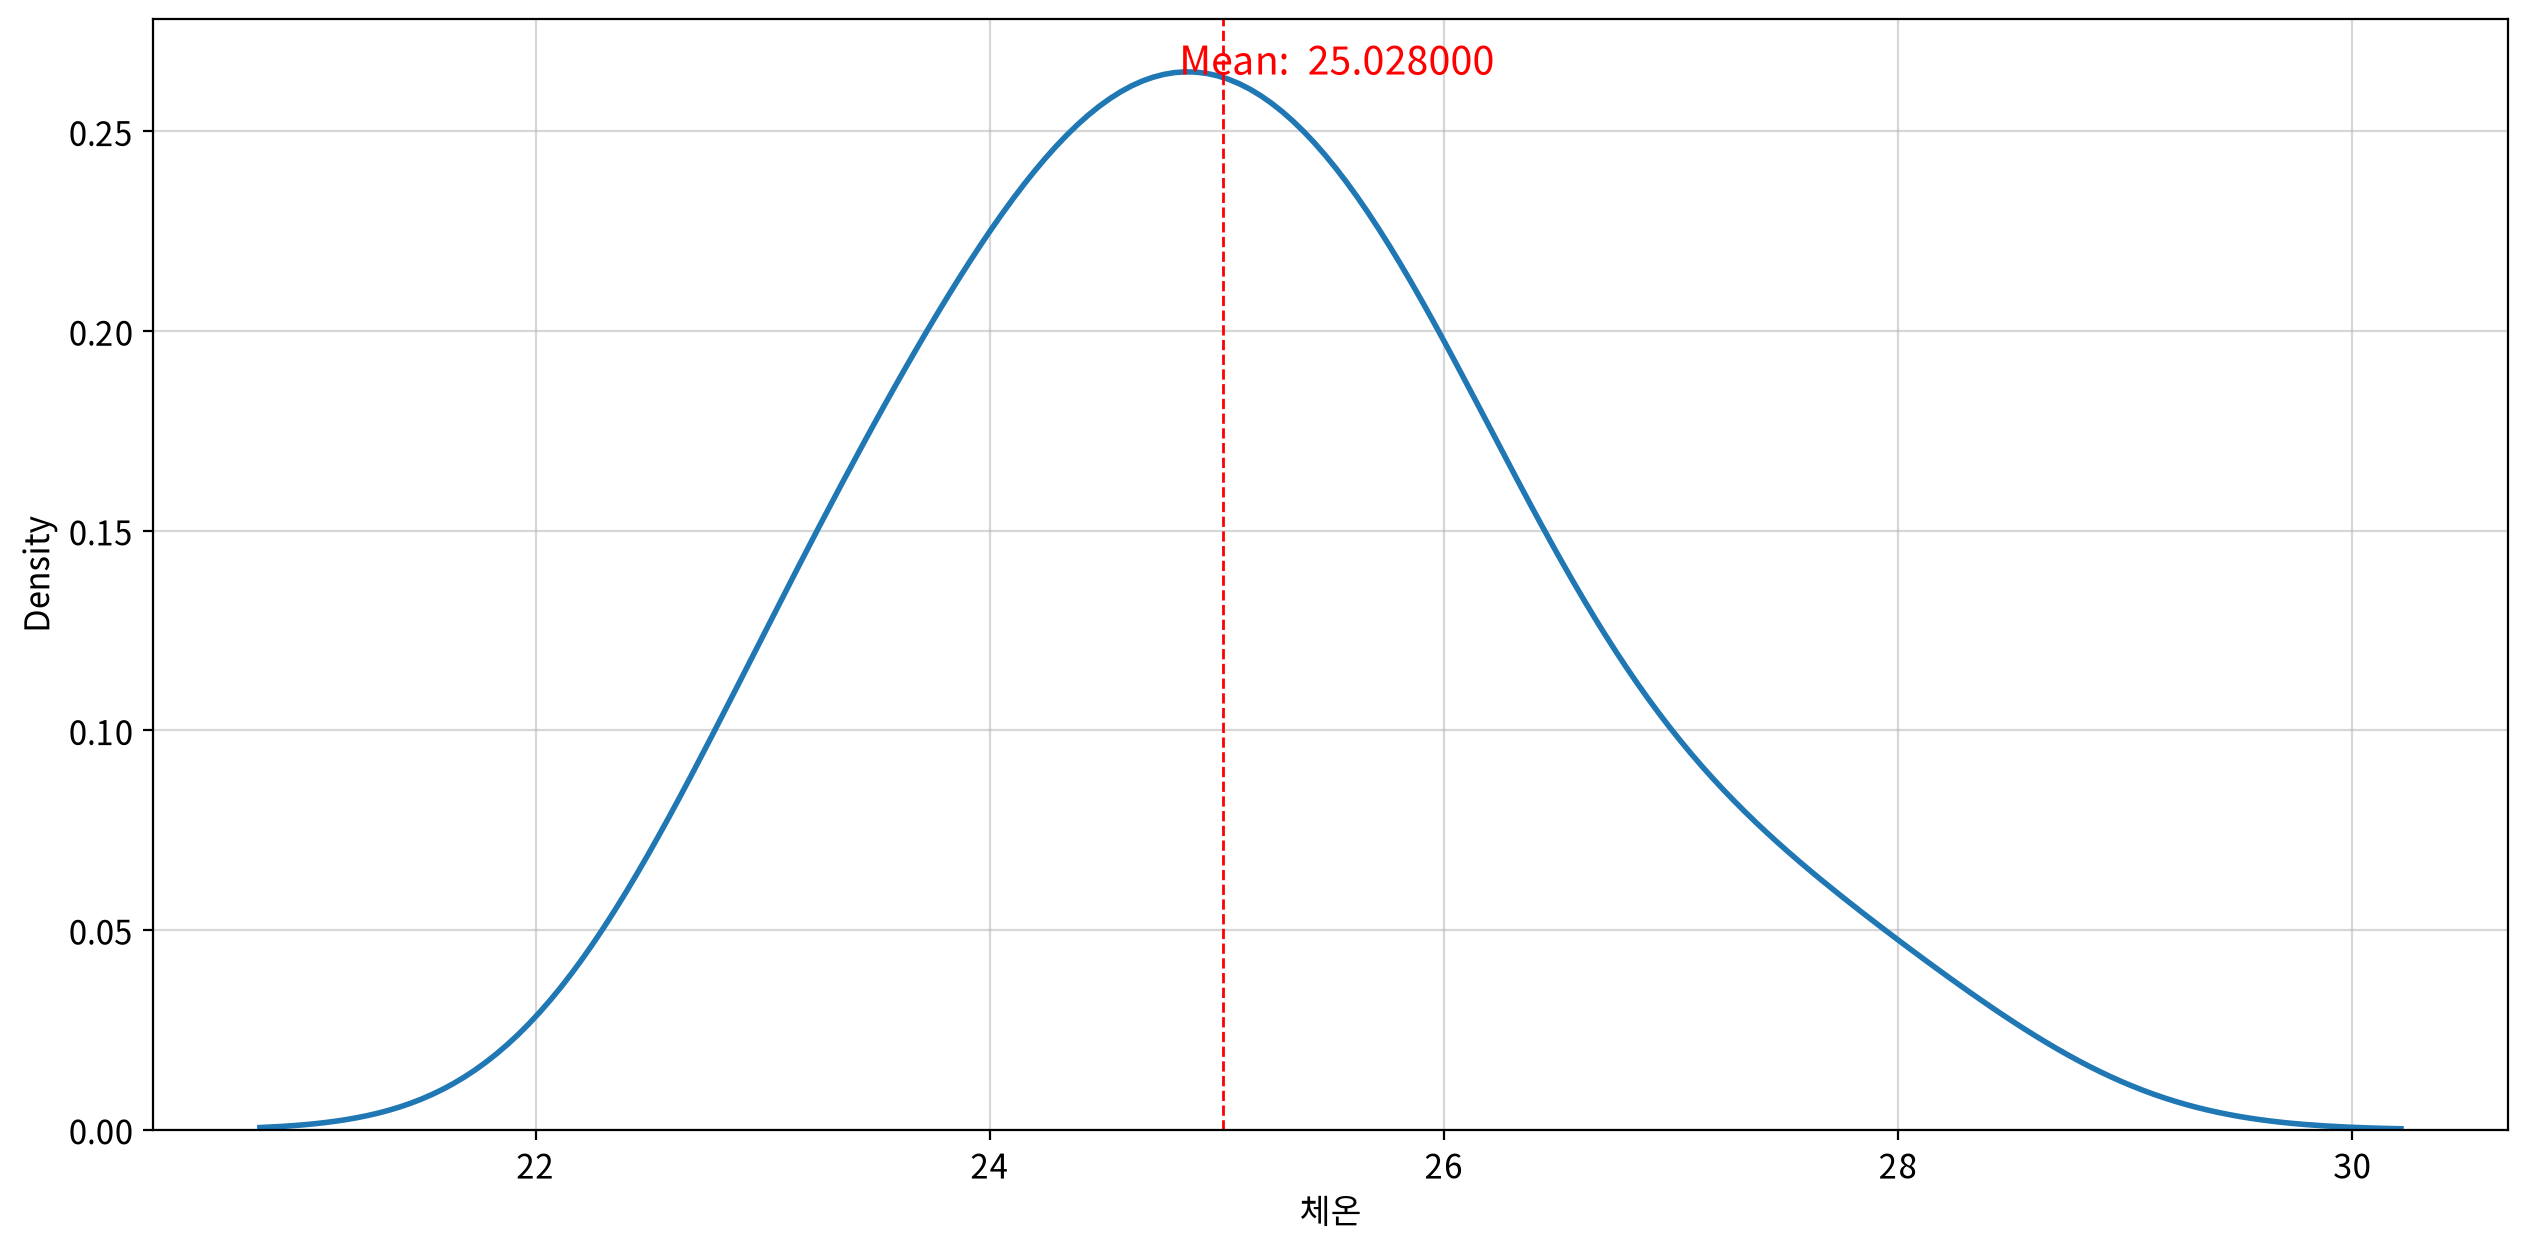

In [3]:
my_plot.kdeplot(df1, x='체온', meanline=True, clevel=0.95)

> 커널 밀도 함수 그래프의 모양이 정규분포를 띄고 있으며, 표본평균(25.03)이 신뢰구간(24.5 ~ 25.6)에 포함되어 있으므로, 강아지의 체온이 정상범위에 있다고 할 수 있다.    
> 시각화 결과로 정규성 가정을 충족하는것 같지만 정확한 통계량으로 정규성 충족 여부를 확인하기 위해 NormalTest를 수행한다.

### 3. 가설검정의 가정 확인

- helpers 패키지의 test_assumptions 함수는 NormalTest를 통해 정규성을 검정한 결과를 반환한다.

In [4]:
my_stats.test_assumptions(df1, columns=['체온'])

,test,statistic,p-value,result
field,,,,
체온,normaltest,0.819,0.664,True


> `p-value`가 `0.664`로 나타나 ($p > 0.05$) 정규성을 충족하므로 One Sample T-Test를 수행한다. 

### 4. One Sample T-Test 양측검정

- 강아지의 평균 체온이 과거의 자료인 24.3과 달라졌는지 여부
- `alternative` 파라미터는 two-sided가 기본값이므로 양측검정의 경우 생략 가능

| 구분               | 수식            | 내용                                       |
| ------------------ | --------------- | ------------------------------------------ |
| 관측치의 평균       | $\mu$           | 강아지 25마리의 평균 체온               |
| 귀무가설($H_0$)    | $\mu = 24.3$    | 강아지의 평균 체온은 `24.3`과 차이가 없다. |
| 대립가설($H_1$)    | $\mu \neq 24.3$ | 강아지의 평균 체온은 `24.3`과 차이가 있다. |


In [5]:
popmean = 24.3              # 비교 기준값을 변수로 저장
alternative = "two-sided"   # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.0121


> 단일표본 t-검정 결과, t-값은 `2.713`, p-value는 `0.012`로 나타났다.     
> 따라서 귀무가설을 기각하고 대립가설을 채택한다(P < 0.05).    
> 이는 모집단의 평균(24.3)과 표본 평균 사이에 유의한 차이가 있음을 의미한다.

### 5. One Sample T-Test - 좌측 단측검정

- 강아지의 평균 체온이 과거의 자료인 24.3보다 작아졌는지 알고자 하는 경우
  - `alternative` 파라미터에 `less`를 설정한다.

| 구분            | 수식            | 설명                                      |
| --------------- | --------------- | ----------------------------------------- |
| 귀무가설($H_0$) | $\mu \geq 24.3$ | 강아지의 평균 체온은 `24.3`보다 작지 않다 |
| 대립가설($H_1$) | $\mu \lt 24.3$  | 강아지의 평균 체온은 `24.3`보다 작다      |


In [6]:
popmean = 24.3              # 비교 기준값을 변수로 저장
alternative = "less"        # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.9939


> 단일표본 t-검정(alternative='less') 결과, t-값은 `2.713`, p-value는 `0.994`로 나타났다.   
> `p-value`가 `0.05`보다 크므로 귀무가설을 기각할 수 없다($p \geq 0.05$). 즉, 강아지의 평균 체온은 `24.3`보다 작지 않다.

### 6. One Sample T-Test - 우측 단측검정

- 강아지의 평균 체온이 과거의 자료인 `24.3`보다 커졌는지 알고자 하는 경우

| 구분            | 수식            | 설명                                      |
| --------------- | --------------- | ----------------------------------------- |
| 귀무가설($H_0$) | $\mu \leq 24.3$ | 강아지의 평균 체온은 `24.3`보다 크지 않다 |
| 대립가설($H_1$) | $\mu \gt 24.3$  | 강아지의 평균 체온은 `24.3`보다 크다      |


In [7]:
popmean = 24.3              # 비교 기준값을 변수로 저장
alternative = "greater"     # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.0061


> 단일표본 t-검정(alternative='greater') 결과, t-값은 `2.713`, p-value는 `0.006`으로 나타났다.    
> `p-value`가 `0.05`보다 작으므로 귀무가설을 기각하고 대립가설을 채택한다($p < 0.05$). 즉, 강아지의 평균 체온은 `24.3`보다 크다.

## #03. 예제(2) - 생명보험 가입 금액 평균 비교

### 1. 데이터 가져오기

- `insur` 데이터는 어느 보험회사에서 한해 동안 모집한 가입원들에 대한 가입 정보이다.
  - 이 회사에서 올해 실적을 가입원들의 평균 가입금액이 1억원인 것을 목표로 삼았을 때, 이 회사는 목표실적을 달성했다고 볼 수 있는지 검정하라.

In [8]:
df2 = load_data("insur")
df2.head()

📚 어느 보험회사에서 한해 동안 모집한 가입원들에 대한 가입 정보 (출처: 방송통신대학교 통계학개론)

    field     description
--  --------  ------------------------------------------------------
 0  직업      1=육체노동, 2=정신노동(직상인), 3=자영업
 1  교육수준  1=초등학교 이하, 2=중졸 및 고졸, 3=대졸, 4=대학원 졸업
 2  성별      1=남자, 2=여자
 3  나이      숫자
 4  가입금액  단위=천만원
 5  월수입    단위=만원



,직업,교육수준,성별,나이,가입금액,월수입
0,1,2,1,35,15.000,100
1,2,3,1,40,10.000,150
2,2,3,2,36,8.000,120
3,3,4,2,38,12.000,140
4,1,1,1,45,10.000,150


### 2. 데이터 분포 시각화

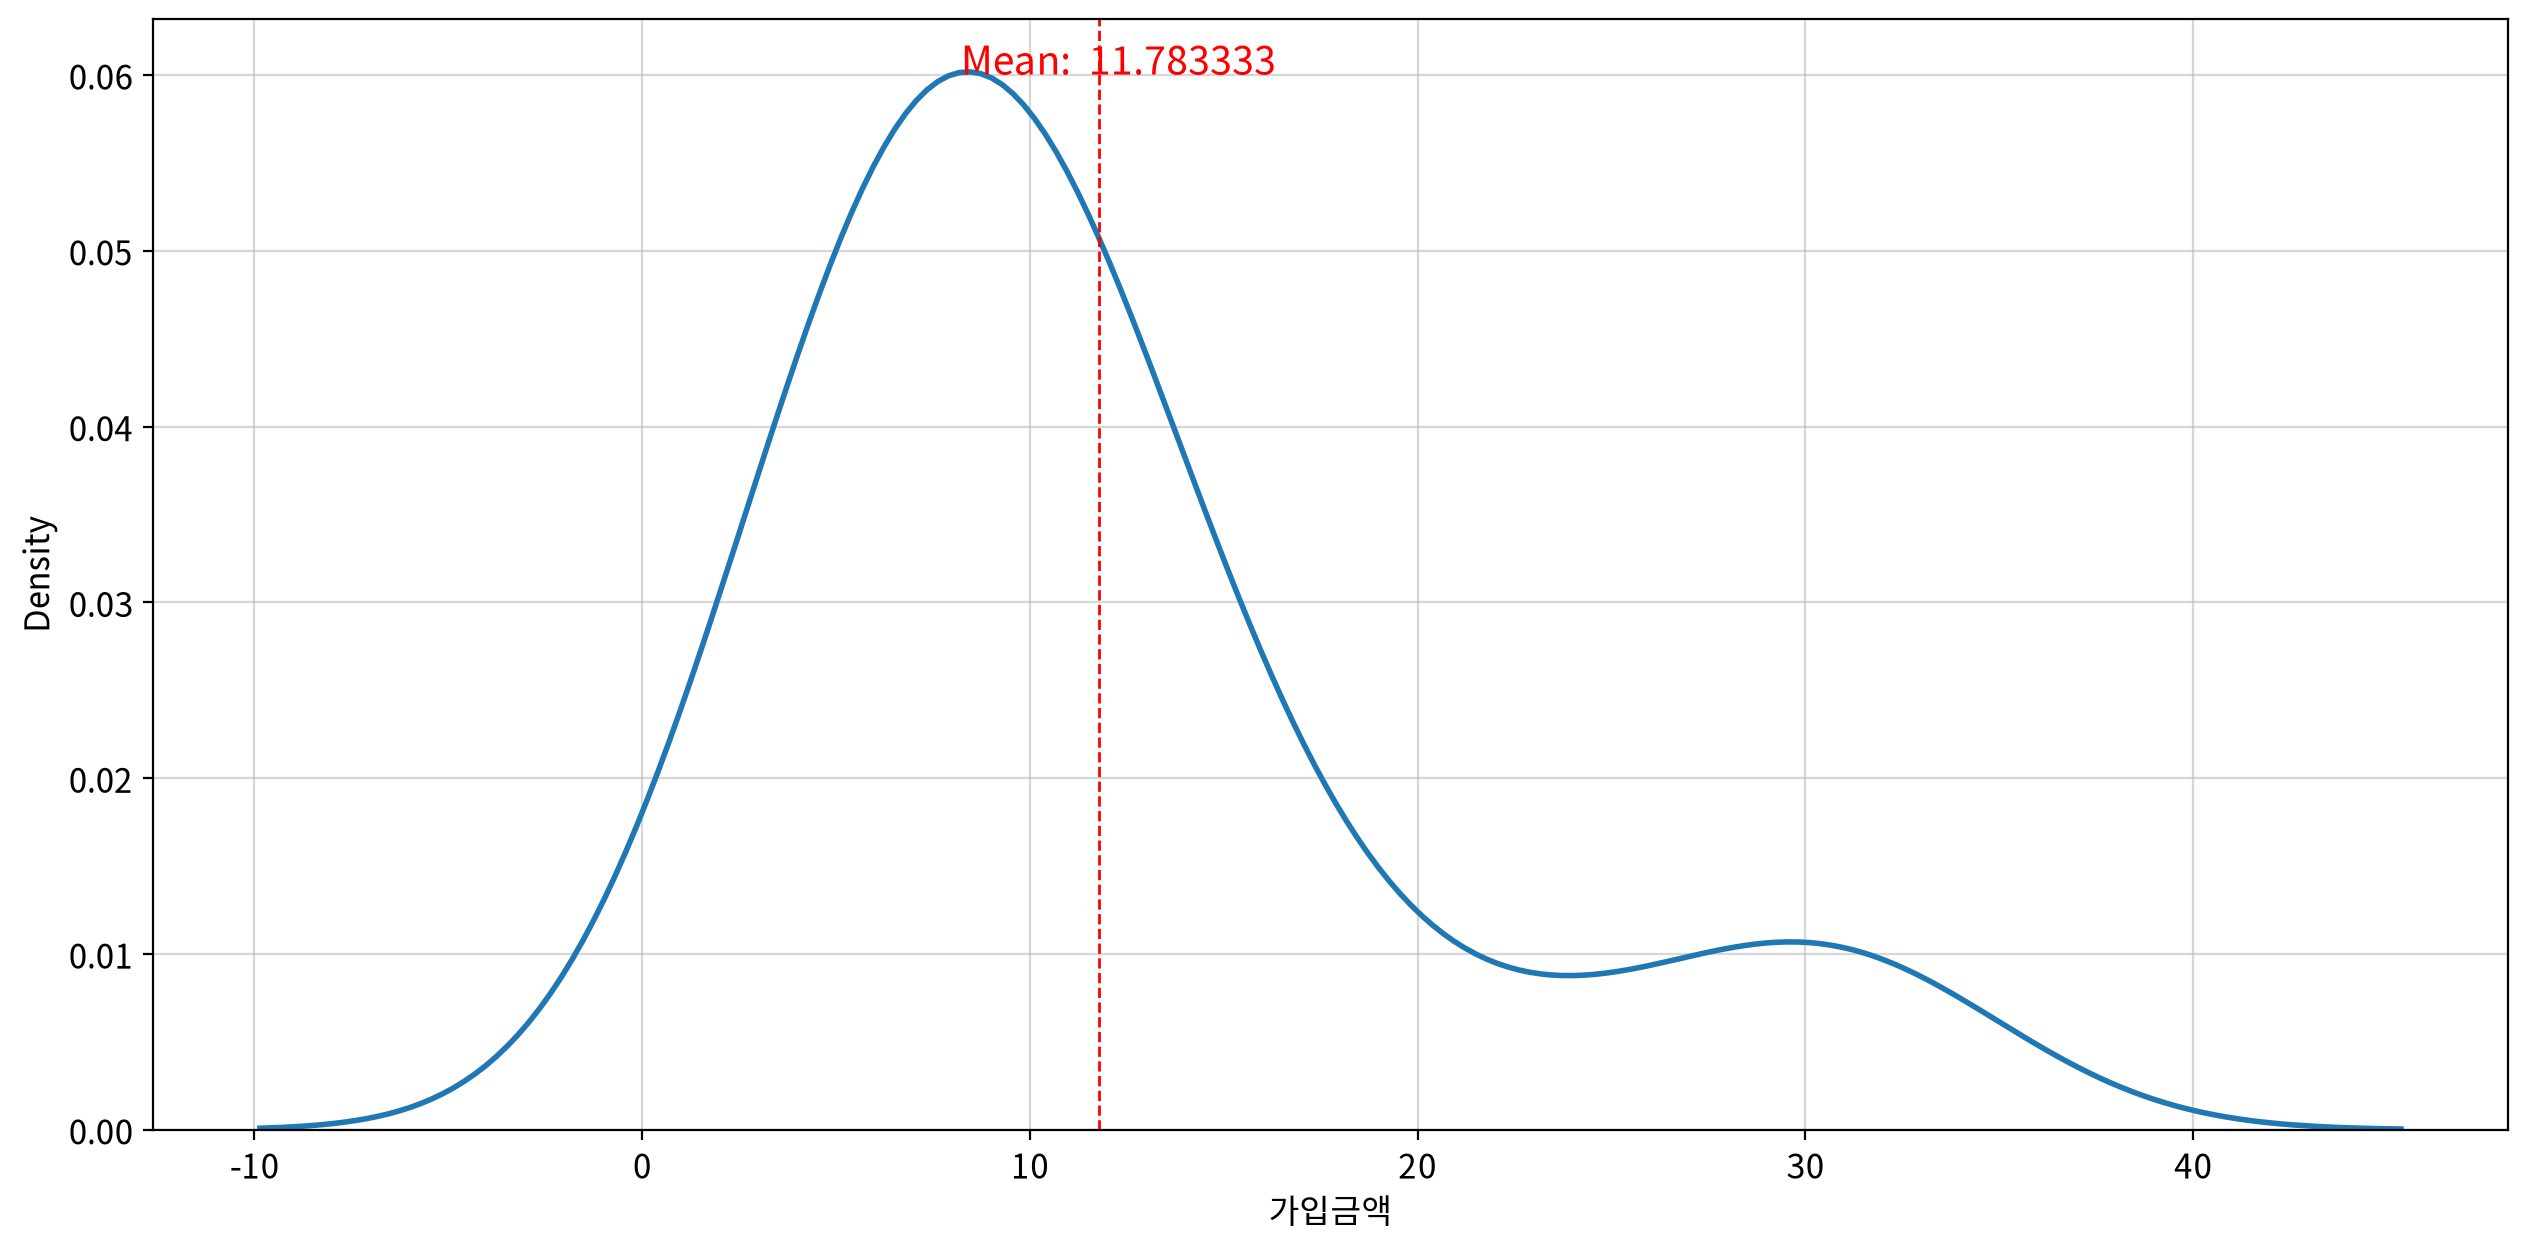

In [9]:
my_plot.kdeplot(df2, x='가입금액', meanline=True, clevel=0.95)

> 표본평균(11.8)이 신뢰구간(8.7 ~ 14.8)에 포함되어 있으므로 가입금액의 데이터는 정상범위에 있다고 할 수 있지만, 커널 밀도 함수 그래프의 모양을 보았을 때 정규분포를 만족하지는 않고 있다.

### 3. 데이터의 정규성 검정

In [10]:
my_stats.test_assumptions(df2, columns='가입금액')

,test,statistic,p-value,result
field,,,,
가입금액,normaltest,11.438,0.003,False


> 주어진 데이터는 `p-value`가 `0.003`이므로 정규성을 충족하지 않는다 ($p < 0.05$).     
> One Sample T-Test를 사용하지 않고 **Willcoxon Signed Rank Test**를 수행해야 한다.

### 4. Willcoxon Signed Rank Test - 양측검정

- 가입금액의 평균이 1억원과 같은지, 다른지 여부

| 구분            | 수식            | 설명                                                    |
| --------------- | --------------- | ------------------------------------------------------- |
| 귀무가설($H_0$) | $\mu = 1억$    | 생명보험의 가입금액 평균은 `1억원`과 차이가 없다.         |
| 대립가설($H_1$) | $\mu \neq 1억$ | 생명보험의 가입금액 평균은 `1억원`과 차이가 있다. |


In [11]:
# 천만원 단위에서 1억원
target_value = 10.0

# 기준값을 뺀 차이에 대한 Wilcoxon 부호순위 검정
s, p = wilcoxon(df2['가입금액'] - target_value)
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 183.5000, p-value: 0.8948


> Wilcoxon Signed Rank Test 결과 보험 가입금액의 모평균이 1억원이라는 귀무가설을 기각할 수 없다($p \geq 0.05$).  
> 즉, 보험 가입금액의 평균은 1억원이다.

### 5. 좌측 단측검정

- 가입금액의 평균이 1억원보다 작은지 여부

| 구분            | 수식            | 설명                                            |
| --------------- | --------------- | ----------------------------------------------- |
| 귀무가설($H_0$) | $\mu \geq 1억$ | 생명보험의 가입금액 평균은 `1억원`보다 작지 않다. |
| 대립가설($H_1$) | $\mu < 1억$    | 생명보험의 가입금액 평균은 `1억원`보다 작다.      |


In [12]:
s, p = wilcoxon(df2['가입금액'] - target_value, alternative='less')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 194.5000, p-value: 0.5526


> Wilcoxon Signed Rank Test를 통한 좌측 단측검정 결과 보험 가입금액의 모평균이 1억원보다 작지 않다는 귀무가설을 기각할 수 없다($p \geq 0.05$)

### 6. 우측 단측검정

- 가입금액의 평균이 1억원보다 큰지 여부

| 구분            | 수식            | 설명                                            |
| --------------- | --------------- | ----------------------------------------------- |
| 귀무가설($H_0$) | $\mu \leq 1억$ | 생명보험의 가입금액 평균은 `1억`보다 크지 않다. |
| 대립가설($H_1$) | $\mu > 1억$    | 생명보험의 가입금액 평균은 `1억`보다 크다.      |


In [13]:
s, p = wilcoxon(df2['가입금액'] - target_value, alternative='greater')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 194.5000, p-value: 0.4474


> Wilcoxon Signed Rank Test를 통한 우측 단측검정 결과 보험 가입금액의 모평균이 1억원보다 크지 않다는 귀무가설을 기각할 수 없다($p \geq 0.05$)

## #04. 모듈기능 확인

### 1. 강아지 체온 변화

In [14]:
my_stats.test_1sample(df1, column='체온', popmean=24.3, alpha=0.05)

statistic  p-value  significant    result
test              alternative                                           
One-sample t-test two-sided        2.713    0.012         True  μ ≠ 24.3
                  less             2.713    0.994        False  μ = 24.3
                  greater          2.713    0.006         True  μ > 24.3

### 2. 생명보험 가입 금액 평균 비교

In [15]:
my_stats.test_1sample(df2, column=('가입금액'), popmean=10)

statistic  p-value  significant  result
test                      alternative                                         
Wilcoxon signed-rank test two-sided      183.500    0.895        False  μ = 10
                          less           194.500    0.553        False  μ = 10
                          greater        194.500    0.447        False  μ = 10

## 연습문제 . 빵집의 양심
### 데이터 : bread
### 초코빵의 무게는 500g이다.
### 그래서 1개월가나 초코빵을 사온 뒤 매일 무게를 기록하였다.
### 25일간 측정한 빵의 평균 무게는 480g 이었다.

In [16]:
df = load_data('bread')
df.info()
df

📚 매일 아침 동네 빵집에서 식빵을 구입해 무게를 기록한 데이터
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   무게      25 non-null     int64
dtypes: int64(1)
memory usage: 332.0 bytes


,무게
0,482
1,479
2,485
3,474
4,479
5,477
6,482
7,480
8,480
9,483


In [17]:
my_stats.test_1sample(df, column='무게', popmean=500)

statistic  p-value  significant   result
test              alternative                                          
One-sample t-test two-sided      -37.524    0.000         True  μ ≠ 500
                  less           -37.524    0.000         True  μ < 500
                  greater        -37.524    1.000        False  μ = 500